In [867]:
import matplotlib.pyplot as plt
import numpy as np
from os import listdir
import pandas as pd 

In [1528]:
replay_id   = 342874
replay_dir  = "../output/replays/"
file_id     = next(f for f in listdir(replay_dir) if f.startswith(f"replay_{replay_id}"))
data        = np.load(replay_dir + file_id)


In [1529]:
data[:, 1]  = data[:, 1].astype(int)
data        = data[np.argsort(data[:, 0])] 

In [1530]:
keys        = [0, 1, 2, 3]

In [1531]:
t_max   = np.ceil(data[:, 0].max())          # next integer second
t_edges = np.arange(0, t_max + 1, 1.0)       # e.g. 0,1,2,…,t_max
n_bins  = len(t_edges) - 1                   # number of 1‑s bins

In [1532]:
output_freq = 1     
dt = 1 / output_freq

t_max = np.ceil(data[:, 0].max() / dt) * dt
t_edges = np.arange(0, t_max + dt, dt)
n_bins = len(t_edges) - 1


In [1533]:
counts = np.zeros((n_bins, len(keys)), dtype=int)

In [1534]:
for k in keys:
    times_k = data[data[:, 1] == k, 0]
    counts[:, k] = np.histogram(times_k, bins=t_edges)[0] 

In [1535]:

def avg_interval_per_bin(event_times: np.ndarray,
                         edges:       np.ndarray,
                         keep_longer: bool = False) -> np.ndarray:
    """
    1. Compute every successive interval  Δt = t[j+1] - t[j]
    2. Assign that Δt to the bin that contains the LATER note t[j+1]
    3. Optionally discard intervals > bin_width (default = discard, per your rule)
    4. Return the arithmetic mean of intervals in each bin; fallback = global mean

    Parameters
    ----------
    event_times : 1-D array of event timestamps (unsorted OK)
    edges       : 1-D array of bin edges (length N+1, uniform or not)
    keep_longer : if True, keep all intervals; if False, drop Δt > bin_width

    Returns
    -------
    avg_int : 1-D array of length N (one value per bin)
    """
    if len(event_times) < 2:
        # not enough data → single fallback for every bin
        return np.full(len(edges) - 1, 1.0)

    # ------------------------------------------------------------------
    # Step 0  •  pre-compute helpers
    # ------------------------------------------------------------------
    times      = np.sort(event_times)
    dt         = np.diff(times)            # all successive intervals
    later      = times[1:]                 # the note that owns each dt
    bins_later = np.clip(
        np.digitize(later, edges) - 1,     # 0-based bin index
        0, len(edges) - 2
    )

    # bin_width varies if edges are non-uniform; use local width per interval
    if not keep_longer:
        # find edge index for each later time (already have bins_later)
        width_per_dt = edges[bins_later + 1] - edges[bins_later]
        mask         = dt <= width_per_dt   # keep only “short” intervals
        dt           = dt[mask]
        bins_later   = bins_later[mask]

    # ------------------------------------------------------------------
    # Step 1  •  accumulate sums and counts per bin
    # ------------------------------------------------------------------
    n_bins = len(edges) - 1
    sum_dt = np.zeros(n_bins, dtype=float)
    cnt_dt = np.zeros(n_bins, dtype=int)

    np.add.at(sum_dt, bins_later, dt)
    np.add.at(cnt_dt, bins_later, 1)

    # ------------------------------------------------------------------
    # Step 2  •  arithmetic mean with global fallback
    # ------------------------------------------------------------------
    global_avg = np.mean(dt)          # dt is never empty here
    avg_int    = np.where(cnt_dt > 0, sum_dt / cnt_dt, global_avg)

    return avg_int

def interval_score(events0, events1, avg_interval, edges):
    """
    Score each event0 against the closest prior event1.
    The average interval array is assumed to be length N = len(edges)-1,
    with bin i covering [edges[i], edges[i+1]).
    """
    # ---- 1. inputs ----
    t0 = np.asarray(events0, dtype=float)
    t1 = np.sort(events1)                    # ensure ascending

    # ---- 2. closest prior event1 ----
    idx1  = np.searchsorted(t1, t0, side='right') - 1
    valid = idx1 >= 0                        # has predecessor?
    delta = np.full_like(t0, np.nan)
    delta[valid] = t0[valid] - t1[idx1[valid]]

    # ---- 3. per-event bin & average interval ----
    n_bins  = len(edges) - 1
    bin_idx = np.clip(np.digitize(t0, edges) - 1, 0, n_bins - 1)
    half_avg = avg_interval[bin_idx] * 0.5

    # ---- 4. score ----
    with np.errstate(divide='ignore', invalid='ignore'):
        score = 1.0 - np.abs(delta - half_avg) / half_avg
        score = np.clip(score, 0.0, 1.0)
        score[~valid | (half_avg == 0)] = np.nan

    return score, bin_idx

In [1536]:
def avg_interval_per_bin_(event_times: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Return a vector (length n_bins) of average inter‑event intervals per 1‑s bin.
       Empty or single‑event bins fall back to the *global* mean interval."""
    if len(event_times) > 1:
        global_avg = np.mean(np.diff(np.sort(event_times)))
    else:
        global_avg = 1.0

    avg_int = np.full(len(edges) - 1, global_avg)

    for i in range(len(edges) - 1):
        in_bin = event_times[(event_times >= edges[i]) & (event_times < edges[i+1])]
        if len(in_bin) > 1:
            avg_int[i] = np.mean(np.diff(in_bin))

    return avg_int      

def interval_score_(events0, events1, avg_interval, edges):
    """Return per‑event scores and their bin indices (0 … n_bins‑1)."""
    t0      = events0
    t1      = events1

    # closest PRIOR event1 for each event0
    idx1    = np.searchsorted(t1, t0, side='right') - 1
    valid   = idx1 >= 0
    delta   = np.full_like(t0, np.nan, dtype=float)
    delta[valid] = t0[valid] - t1[idx1[valid]]

    # bin index of each event0
    bin_idx = np.clip(np.digitize(t0, edges) - 1, 0, len(edges) - 2)

    # per‑event average interval
    half_avg = avg_interval[bin_idx] / 2.0

    with np.errstate(divide='ignore', invalid='ignore'):
        score = 1.0 - np.abs(delta - half_avg) / half_avg
        score = np.clip(score, 0, 1)
        score[~valid | (half_avg == 0)] = np.nan

    return score, bin_idx

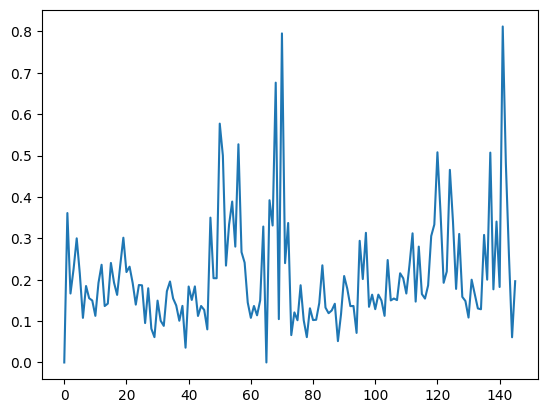

In [1537]:
gap0      = np.diff(data[data[:,1]==0, 0])
rough0    = np.abs(gap0[:-1] - gap0[1:]) / (gap0[:-1] + gap0[1:])

# assign each roughness value to the bin of its LATER gap
later_gap_time = data[data[:,1]==0, 0][2:]          # third note onward
bin_idx        = np.digitize(later_gap_time, t_edges) - 1
rough_sum      = np.zeros(len(t_edges)-1)
cnt            = np.zeros_like(rough_sum)
np.add.at(rough_sum, bin_idx, rough0)
np.add.at(cnt,       bin_idx, 1)
rough_avg_per_bin = rough_sum / np.maximum(cnt, 1)   # mean roughness

plt.plot(rough_avg_per_bin)

In [1538]:
avg_int_k0 = avg_interval_per_bin(data[data[:, 1] == 0, 0], t_edges)
avg_int_k1 = avg_interval_per_bin(data[data[:, 1] == 1, 0], t_edges)
avg_int_k2 = avg_interval_per_bin(data[data[:, 1] == 2, 0], t_edges)
avg_int_k3 = avg_interval_per_bin(data[data[:, 1] == 3, 0], t_edges)
avg_int_h0 = np.minimum(avg_int_k0, avg_int_k1)  
avg_int_h1 = np.minimum(avg_int_k2, avg_int_k3)  

/var/folders/w9/mbrmw1tj0vq7b0vxc3ytvprm0000gn/T/ipykernel_82899/1904409093.py:57: RuntimeWarning: invalid value encountered in divide
  avg_int    = np.where(cnt_dt > 0, sum_dt / cnt_dt, global_avg)


In [1539]:
# Scores for key‑0→key‑1 and key‑1→key‑0 pairs
score_k01, bin_k01 = interval_score(data[data[:, 1] == 0, 0],
                                    data[data[:, 1] == 1, 0],
                                    avg_int_h0, t_edges)

score_k10, bin_k10 = interval_score(data[data[:, 1] == 1, 0],
                                    data[data[:, 1] == 0, 0],
                                    avg_int_h0, t_edges)

score_k23, bin_k23 = interval_score(data[data[:, 1] == 2, 0],
                                    data[data[:, 1] == 3, 0],
                                    avg_int_h1, t_edges)

score_k32, bin_k32 = interval_score(data[data[:, 1] == 3, 0],
                                    data[data[:, 1] == 2, 0],
                                    avg_int_h1, t_edges)

In [1540]:
trill_intensity = np.zeros((n_bins, len(keys)), dtype=float)

valid_01 = ~np.isnan(score_k01)
np.add.at(trill_intensity[:, 0], bin_k01[valid_01], score_k01[valid_01])

valid_10 = ~np.isnan(score_k10)
np.add.at(trill_intensity[:, 1], bin_k10[valid_10], score_k10[valid_10])

valid_23 = ~np.isnan(score_k23)
np.add.at(trill_intensity[:, 2], bin_k23[valid_23], score_k23[valid_23])

valid_32 = ~np.isnan(score_k32)
np.add.at(trill_intensity[:, 3], bin_k32[valid_32], score_k32[valid_32])

In [1541]:
jack_tension = (np.max(counts[:,[0,1]],axis=1) + np.max(counts[:,[2,3]],axis=1))

In [1542]:
data

array([[  0.56300004,   0.        ],
       [  0.56300004,   3.        ],
       [  0.60565883,   2.        ],
       ...,
       [145.21872025,   3.        ],
       [145.26138611,   0.        ],
       [145.26138611,   1.        ]], shape=(3221, 2))

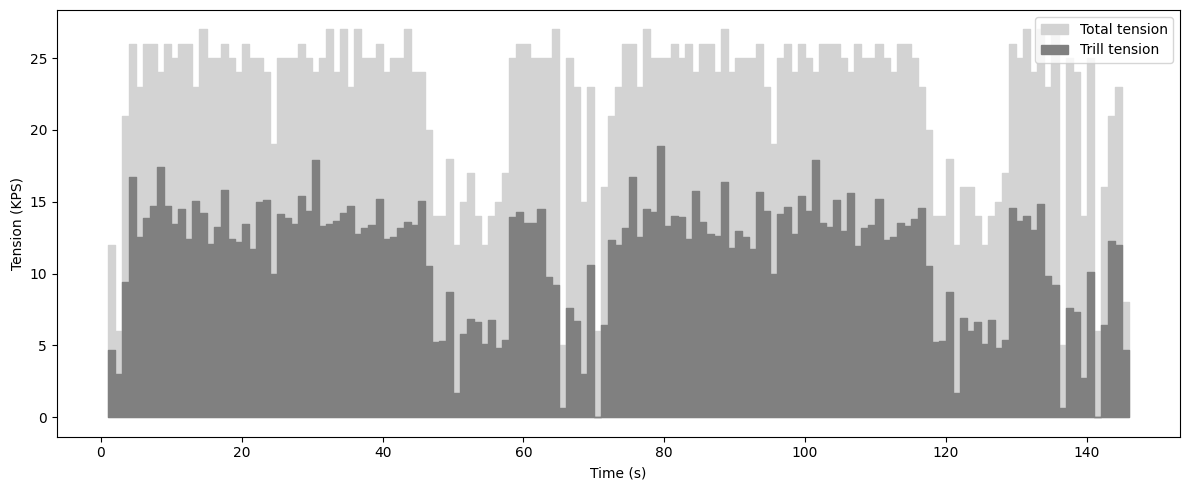

In [1543]:
plt.figure(figsize=(12, 5))

# Fill under the 'counts' curve (light gray)
plt.fill_between(t_edges[1:], counts.sum(axis=1), color='lightgray', step='pre', label='Total tension')

# Fill under the 'trill intensity' curve (gray), on top
plt.fill_between(t_edges[1:], trill_intensity.sum(axis=1), color='gray', step='pre', label='Trill tension')

plt.xlabel('Time (s)')
plt.ylabel('Tension (KPS)')
plt.legend()
plt.tight_layout()
plt.show()

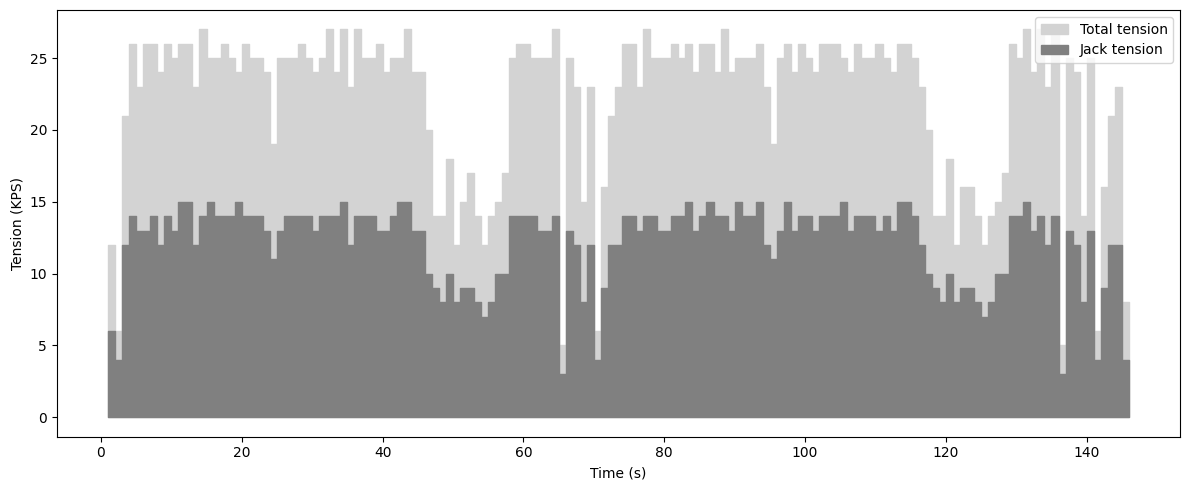

In [1544]:
plt.figure(figsize=(12, 5))

# Fill under the 'counts' curve (light gray)
plt.fill_between(t_edges[1:], counts.sum(axis=1), color='lightgray', step='pre', label='Total tension')

# Fill under the 'trill intensity' curve (gray), on top
plt.fill_between(t_edges[1:], jack_tension, color='gray', step='pre', label='Jack tension')

plt.xlabel('Time (s)')
plt.ylabel('Tension (KPS)')
plt.legend()
plt.tight_layout()
plt.show()

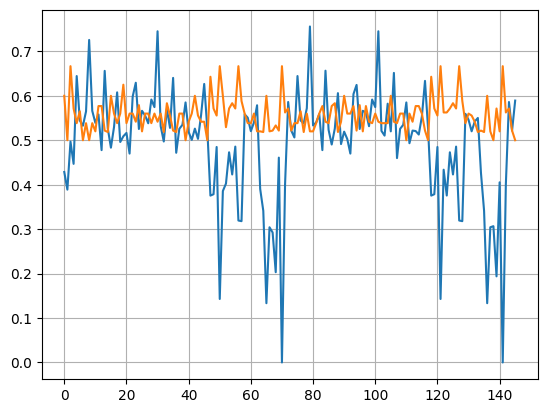

In [1545]:
plt.plot(trill_intensity[:,:].sum(axis=1)/(counts[:,:].sum(axis=1) + 1e-10))
plt.plot(jack_tension/(counts[:,:].sum(axis=1) + 1e-10))
plt.grid()

In [1546]:
(trill_intensity[:,:].sum(axis=1)/(counts[:,:].sum(axis=1) + 1e-10)).mean()

np.float64(0.4919028610858862)

In [1547]:
(jack_tension/(counts[:,:].sum(axis=1) + 1e-10)).mean()

np.float64(0.5562453124166437)

---

In [1470]:
def get_tensions(replay_id):
    replay_dir  = "../output/replays/"
    file_id     = next(f for f in listdir(replay_dir) if f.startswith(f"replay_{replay_id}"))
    data        = np.load(replay_dir + file_id)

    data[:, 1]  = data[:, 1].astype(int)
    data        = data[np.argsort(data[:, 0])] 
    keys        = [0, 1, 2, 3]
    t_max   = np.ceil(data[:, 0].max())          # next integer second
    t_edges = np.arange(0, t_max + 1, 1.0)       # e.g. 0,1,2,…,t_max
    n_bins  = len(t_edges) - 1                   # number of 1‑s bins
    output_freq = 1     # Example: 2 Hz
    dt = 1 / output_freq

    t_max = np.ceil(data[:, 0].max() / dt) * dt
    t_edges = np.arange(0, t_max + dt, dt)
    n_bins = len(t_edges) - 1

    counts = np.zeros((n_bins, len(keys)), dtype=int)
    for k in keys:
        times_k = data[data[:, 1] == k, 0]
        counts[:, k] = np.histogram(times_k, bins=t_edges)[0] 
         
    
    avg_int_k0 = avg_interval_per_bin(data[data[:, 1] == 0, 0], t_edges)
    avg_int_k1 = avg_interval_per_bin(data[data[:, 1] == 1, 0], t_edges)
    avg_int_k2 = avg_interval_per_bin(data[data[:, 1] == 2, 0], t_edges)
    avg_int_k3 = avg_interval_per_bin(data[data[:, 1] == 3, 0], t_edges)
    avg_int_h0 = np.minimum(avg_int_k0, avg_int_k1)  
    avg_int_h1 = np.minimum(avg_int_k2, avg_int_k3)  
    # Scores for key‑0→key‑1 and key‑1→key‑0 pairs
    score_k01, bin_k01 = interval_score(data[data[:, 1] == 0, 0],
                                        data[data[:, 1] == 1, 0],
                                        avg_int_h0, t_edges)

    score_k10, bin_k10 = interval_score(data[data[:, 1] == 1, 0],
                                        data[data[:, 1] == 0, 0],
                                        avg_int_h0, t_edges)

    score_k23, bin_k23 = interval_score(data[data[:, 1] == 2, 0],
                                        data[data[:, 1] == 3, 0],
                                        avg_int_h1, t_edges)

    score_k32, bin_k32 = interval_score(data[data[:, 1] == 3, 0],
                                        data[data[:, 1] == 2, 0],
                                        avg_int_h1, t_edges)
    trill_intensity = np.zeros((n_bins, len(keys)), dtype=float)

    valid_01 = ~np.isnan(score_k01)
    np.add.at(trill_intensity[:, 0], bin_k01[valid_01], score_k01[valid_01])

    valid_10 = ~np.isnan(score_k10)
    np.add.at(trill_intensity[:, 1], bin_k10[valid_10], score_k10[valid_10])

    valid_23 = ~np.isnan(score_k23)
    np.add.at(trill_intensity[:, 2], bin_k23[valid_23], score_k23[valid_23])

    valid_32 = ~np.isnan(score_k32)
    np.add.at(trill_intensity[:, 3], bin_k32[valid_32], score_k32[valid_32])
    
    return np.quantile((trill_intensity[:,:].sum(axis=1) / (counts.sum(axis=1) + 1e-10)), 0.75)
    return (trill_intensity[:,:].sum(axis=1) / (counts.sum(axis=1) + 1e-10)).mean()

In [1471]:
df = pd.read_csv("../output/chart_elo_diff.csv")

In [1472]:
res = []
for i in df["chart_id"].to_list():
    try:
        res += [get_tensions(i)]
    except:
        res += [np.nan]

/var/folders/w9/mbrmw1tj0vq7b0vxc3ytvprm0000gn/T/ipykernel_82899/1904409093.py:57: RuntimeWarning: invalid value encountered in divide
  avg_int    = np.where(cnt_dt > 0, sum_dt / cnt_dt, global_avg)
/Users/yaroslavkorobov/Documents/ELO-vsrg-ranking-public/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/yaroslavkorobov/Documents/ELO-vsrg-ranking-public/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [1473]:
df["tensions"] = res


In [1474]:
df = df.dropna()

In [1475]:
tens = df.tensions.to_numpy()

In [1476]:
elo = df["elo_diff"].to_numpy()

In [1477]:
np.corrcoef(tens[df.skillset != "chordjacks"],elo[df.skillset != "chordjacks"])

array([[1.        , 0.21522113],
       [0.21522113, 1.        ]])

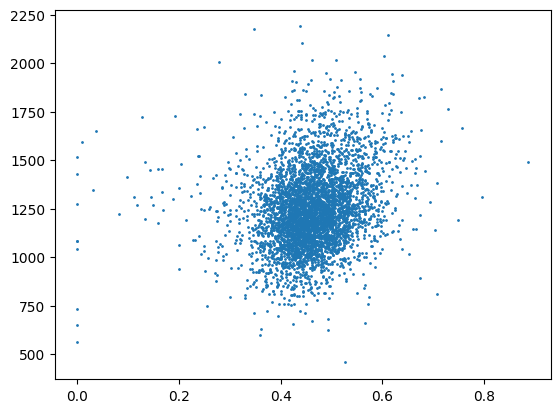

In [1478]:
plt.scatter(tens[df.skillset != "chordjacks"],elo[df.skillset != "chordjacks"],s=1)

In [844]:
tens.shape

(5294,)